In [2]:
import pandas as pd
from datetime import date
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


In [3]:
START_DATE = date(2018, 1, 1)
END_DATE = date(2022, 12, 31)

COVARIATE = "heat_index"  # temp or heat_index
SPLIT = 0.7

PLOT_DATA_FOLDER = Path(f"../data/{COVARIATE}/{COVARIATE}_{START_DATE}_{END_DATE}_{SPLIT}_family_comparison")
METRICS_FILE = PLOT_DATA_FOLDER / "model_family_metrics.csv"
PLOT_OUTPUT_FILE = Path(f"../plots/predictions/family_comparison_{COVARIATE}_{START_DATE}_{END_DATE}_{SPLIT}.png")

assert METRICS_FILE.exists(), f"{METRICS_FILE} does not exist"


In [4]:
metrics = pd.read_csv(METRICS_FILE)
metrics = metrics.sort_values(["family", "model_index"]).copy()
metrics["family_label"] = metrics["family"].map({"poisson": "Poisson", "negbinom2": "Negative binomial (NB2)"})
metrics


,family,model_index,mse,bic,delta_bic,family_label
0,negbinom2,1,12778.927008,106795.418574,1335.856499,Negative binomial (NB2)
1,negbinom2,2,11674.051924,106715.621902,1256.059826,Negative binomial (NB2)
2,negbinom2,3,10934.704748,105896.305207,436.743132,Negative binomial (NB2)
3,negbinom2,4,9637.338730,105602.125147,142.563072,Negative binomial (NB2)
4,negbinom2,5,9329.651437,105596.236909,136.674833,Negative binomial (NB2)
5,negbinom2,6,9328.682407,105459.562075,0.000000,Negative binomial (NB2)
6,poisson,1,10636.468126,710859.956212,389017.461583,Poisson
7,poisson,2,10658.219968,689915.531287,368073.036659,Poisson
8,poisson,3,4441.258350,368632.941127,46790.446498,Poisson
9,poisson,4,4411.208341,343008.536248,21166.041619,Poisson


<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
<>:16: SyntaxWarning: invalid escape sequence '\D'
<>:18: SyntaxWarning: invalid escape sequence '\D'
C:\Users\byz_t\AppData\Local\Temp\ipykernel_7364\2491102828.py:16: SyntaxWarning: invalid escape sequence '\D'
  axes[1].set_title("$\Delta$BIC by model specification")
C:\Users\byz_t\AppData\Local\Temp\ipykernel_7364\2491102828.py:18: SyntaxWarning: invalid escape sequence '\D'
  axes[1].set_ylabel("$\Delta$BIC relative to best family-specific model")


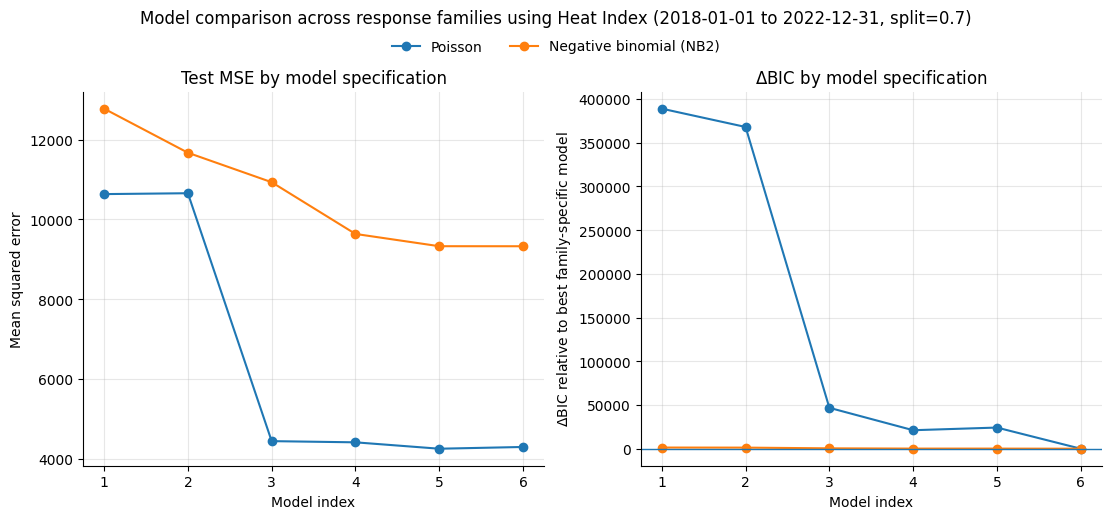

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

for family in ["poisson", "negbinom2"]:
    subset = metrics[metrics["family"] == family]
    label = subset["family_label"].iloc[0]

    axes[0].plot(subset["model_index"], subset["mse"], marker="o", linewidth=1.5, label=label)
    axes[1].plot(subset["model_index"], subset["delta_bic"], marker="o", linewidth=1.5, label=label)

axes[0].set_title("Test MSE by model specification")
axes[0].set_xlabel("Model index")
axes[0].set_ylabel("Mean squared error")
axes[0].set_xticks(sorted(metrics["model_index"].unique()))
axes[0].grid(True, alpha=0.3)

axes[1].set_title("$\Delta$BIC by model specification")
axes[1].set_xlabel("Model index")
axes[1].set_ylabel("$\Delta$BIC relative to best family-specific model")
axes[1].set_xticks(sorted(metrics["model_index"].unique()))
axes[1].axhline(0, linewidth=1)
axes[1].grid(True, alpha=0.3)

for ax in axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, bbox_to_anchor=(0.5, 1.08))

covariate_for_title = "Temperature" if COVARIATE == "temp" else "Heat Index"
fig.suptitle(
    f"Model comparison across response families using {covariate_for_title} ({START_DATE} to {END_DATE}, split={SPLIT})",
    fontsize=12,
    y=1.12,
)

PLOT_OUTPUT_FILE.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(PLOT_OUTPUT_FILE, dpi=300, bbox_inches="tight")
plt.show()
